# PREPARACIÓN DE VISUALIZACIONES SECUNDARIAS PARA ANÁLISIS BIVARIANTE Y MULTIVARIANTE

In [3]:
import pandas as pd
import numpy as np
import glob
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Carga la tabla principal de juegos (bgg_games.csv) usando la función cargar_tabla_juegos
bgg_games = fn.cargar_tabla_juegos('bgg_games')
bgg_expansions = fn.cargar_tabla_juegos('bgg_expansions')
# Carga las tablas de relaciones muchos-a-muchos:
# artistas, diseñadores, mecánicas y categorías (cada una desde su CSV correspondiente)
game_artists = fn.cargar_tabla_juegos('game_artists')
game_designers = fn.cargar_tabla_juegos('game_designers')
game_mechanics = fn.cargar_tabla_juegos('game_mechanics')
game_categories = fn.cargar_tabla_juegos('game_categories')

In [ ]:
bgg_total = pd.concat(
    [juegos_base, expansiones],
    ignore_index=True
)

In [ ]:
# Creamos la columna "popularidad_total" (también conocida como interés medio)
bgg_games["popularidad_total"] = (games_df["owned"] + games_df["wishing"])
games_df = bgg_games

### Gráfico de correlaciones para elegir las variables que se tendrán en cuenta para el diseño inicial de juego:

In [259]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_bgg",
    ["#48a1ea", "#ffffff", "#F8A679"]
)

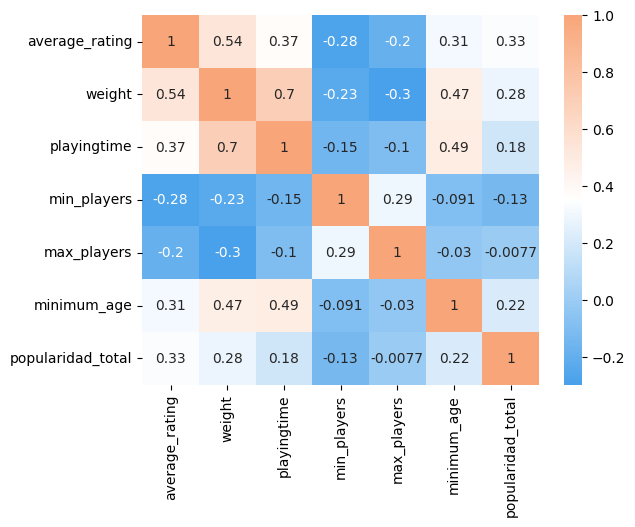

In [ ]:
cols = ["average_rating", "weight", "playingtime", "min_players", "max_players", "minimum_age", "popularidad_total"]

corr = games_df[cols].corr(method="spearman")

sns.heatmap(corr, annot=True, cmap=custom_cmap)
plt.show()

### Correlación entre la valoración y el weight (complejidad) fuerte. Correlación débil entre el tiempo de juego y la complejidad. 

## Una vez filtrados, hacemos el análisis de las mecánicas y categorías

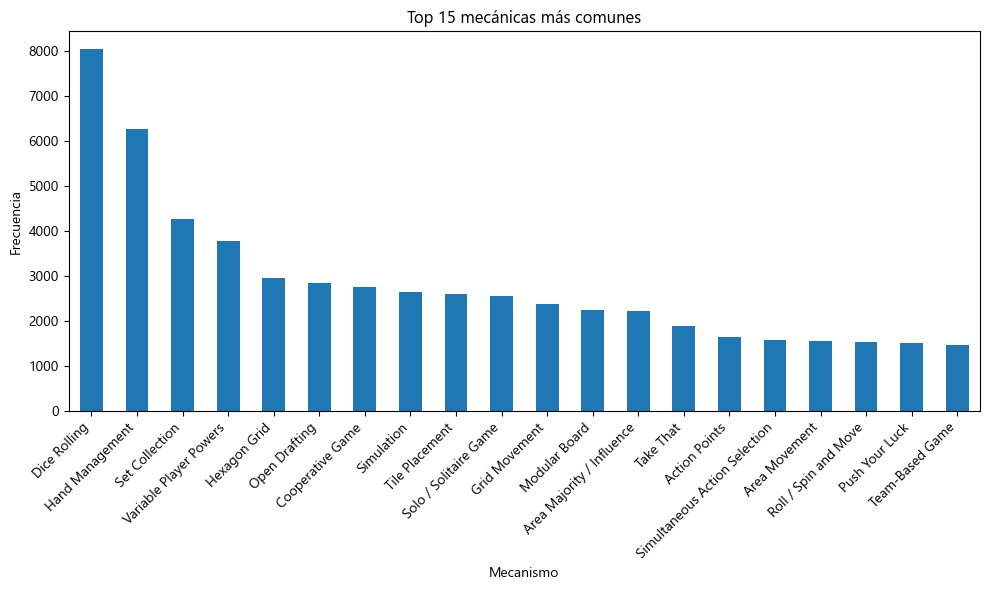

In [25]:
# Representación mecánicas más frecuentes:

df_mecha = games_df.explode("mechanisms")
num_mecha = df_mecha["mechanisms"].value_counts().head(20)

plt.figure(figsize=(10,6))
num_mecha.plot(kind="bar")

plt.title("Top 15 mecánicas más comunes")
plt.xlabel("Mecanismo")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

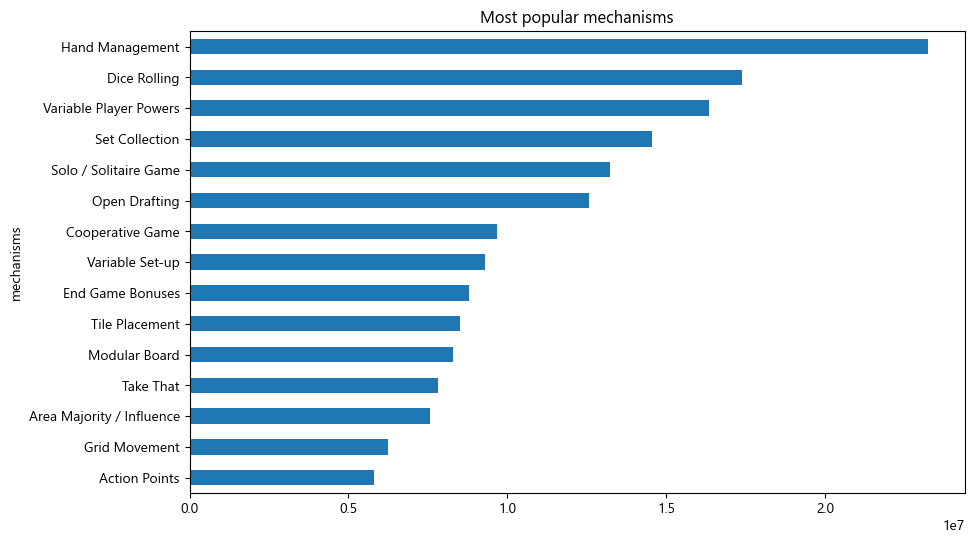

In [44]:
# Representación de las mecánicas en base a su popularidad:

top = games_df.explode("mechanisms").groupby("mechanisms")["popularidad_total"].sum().sort_values(ascending=False).head(15)

top.plot(kind="barh", figsize=(10,6))
plt.gca().invert_yaxis()
plt.title("Most popular mechanisms")
plt.show()
plt.rcParams["font.family"] = "Segoe UI"

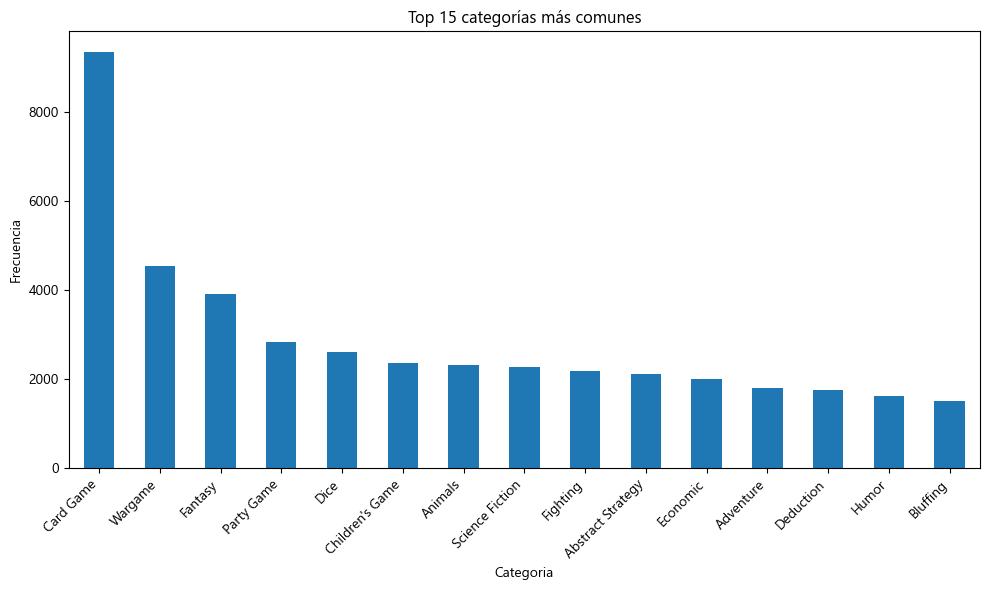

In [27]:
# Representación categorías más frecuentes
df_cat = games_df.explode("categories")
num_cat = df_cat["categories"].value_counts().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
num_cat.plot(kind="bar")

plt.title("Top 15 categorías más comunes")
plt.xlabel("Categoria")
plt.ylabel("Frecuencia")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

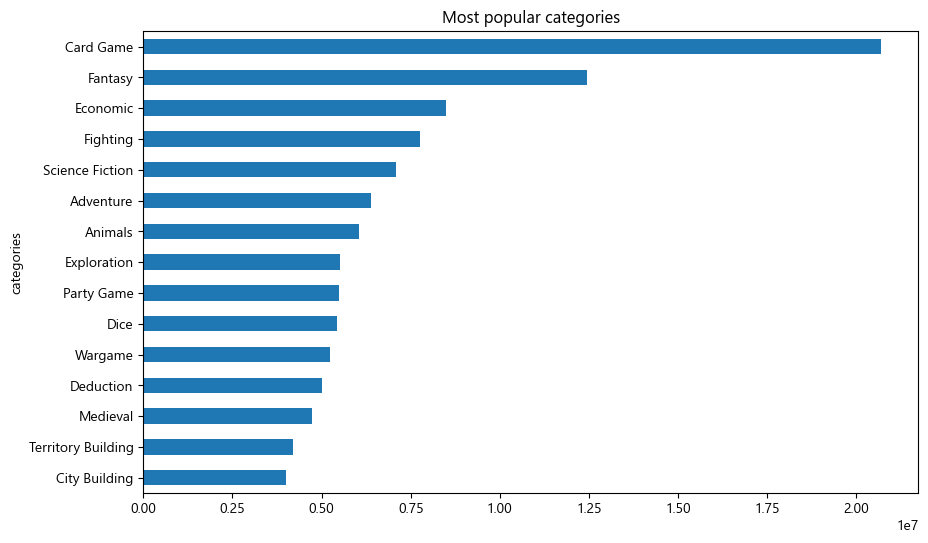

In [43]:
# Representación de las categorías en base a su popularidad:

top = games_df.explode("categories").groupby("categories")["popularidad_total"].sum().sort_values(ascending=False).head(15)

top.plot(kind="barh", figsize=(10,6))
plt.gca().invert_yaxis()
plt.title("Most popular categories")
plt.show()
plt.rcParams["font.family"] = "Segoe UI"

### Para no perder de vista el rating, vamos a quedarnos solo con los juegos que tengan un número de ratings igual o mayor al tercer cuartil de los datos de boardgames solo con filtros (aprox. 460)

In [29]:
votings_selected = games_df[games_df["num_of_ratings"] > 460]

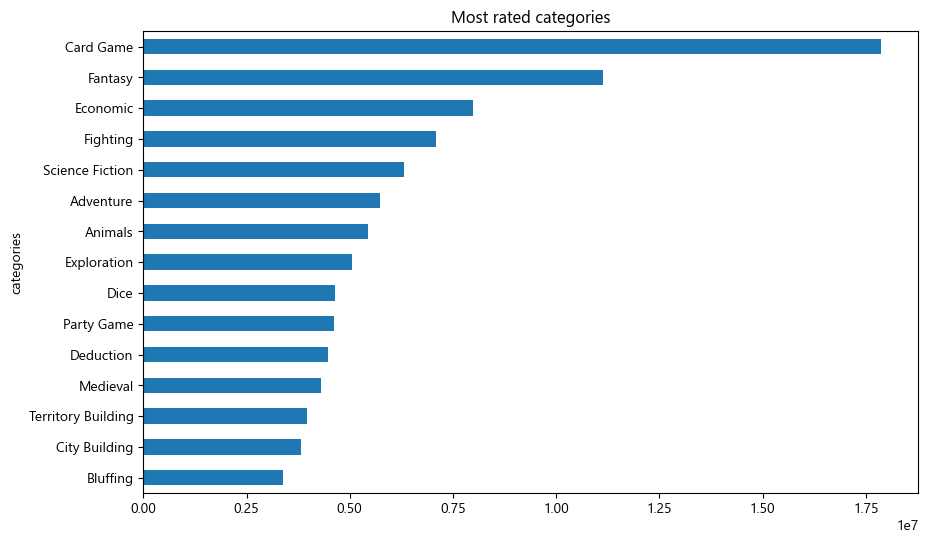

In [45]:
top = votings_selected.explode("categories").groupby("categories")["popularidad_total"].sum().sort_values(ascending=False).head(15)

top.plot(kind="barh", figsize=(10,6))
plt.gca().invert_yaxis()
plt.title("Most rated categories")
plt.show()
plt.rcParams["font.family"] = "Segoe UI"

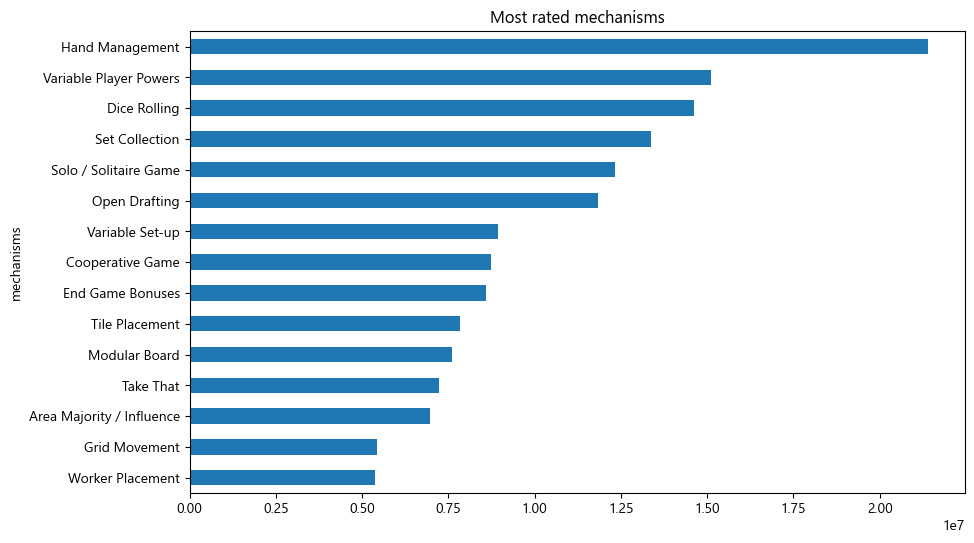

In [46]:
top = votings_selected.explode("mechanisms").groupby("mechanisms")["popularidad_total"].sum().sort_values(ascending=False).head(15)

top.plot(kind="barh", figsize=(10,6))
plt.gca().invert_yaxis()
plt.title("Most rated mechanisms")
plt.show()
plt.rcParams["font.family"] = "Segoe UI"

### Veamos la distribución de las edades

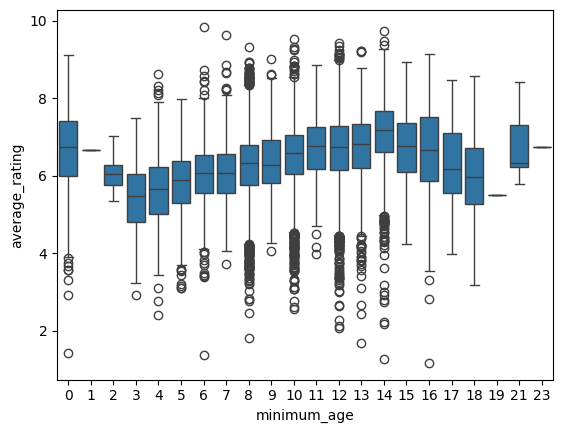

In [229]:
sns.boxplot(
    data=games_df,
    x="minimum_age",
    y="average_rating"
)

plt.show()

### **Edad mínima para el producto de 11 (menor rango intercuartílico y outliers y mayor mediana) o 14 años (mayor mediana)**

### Veamos la distribución del rating en base al número mínimo y máximo de jugadores

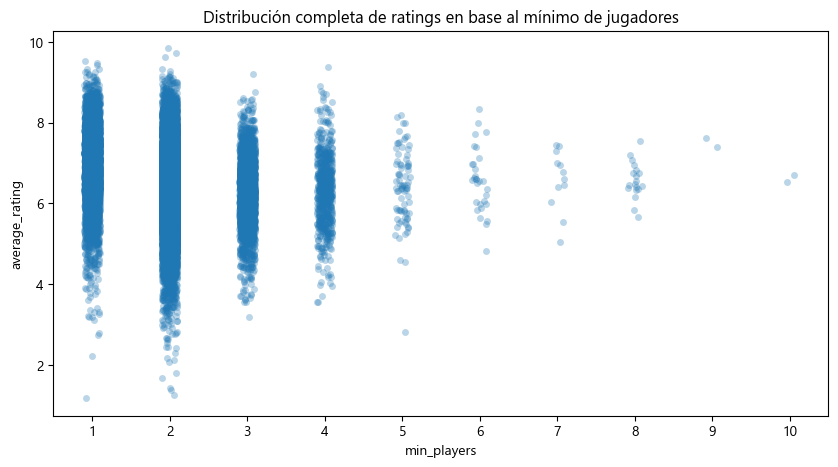

In [34]:
plt.figure(figsize=(10,5))

sns.stripplot(
    data=games_df,
    x="min_players",
    y="average_rating",
    jitter=True,
    alpha=0.3
)

plt.title("Distribución completa de ratings en base al mínimo de jugadores")
plt.show()

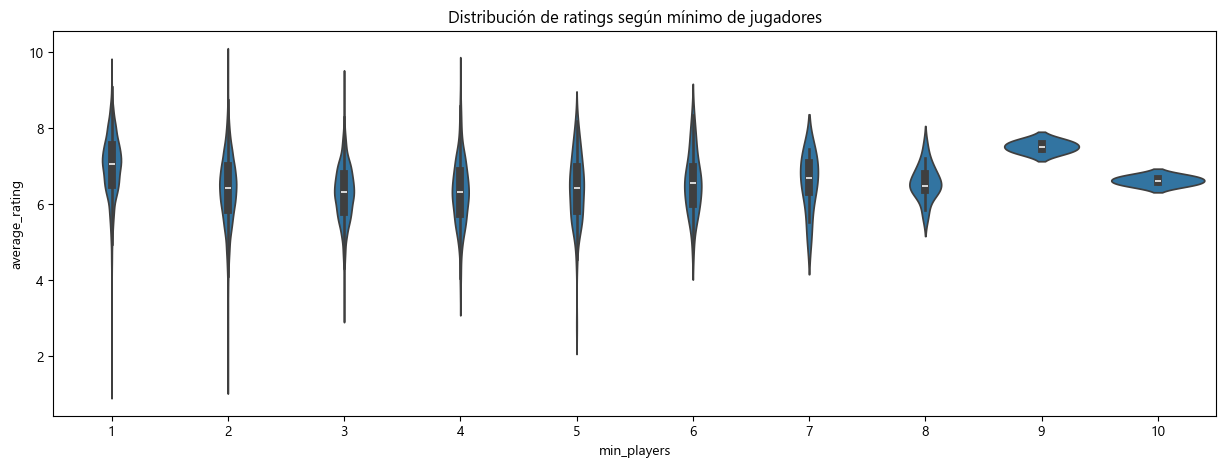

In [42]:
plt.figure(figsize=(15,5))

sns.violinplot(
    data=games_df,
    x="min_players",
    y="average_rating"
)

plt.title("Distribución de ratings según mínimo de jugadores")
plt.show()

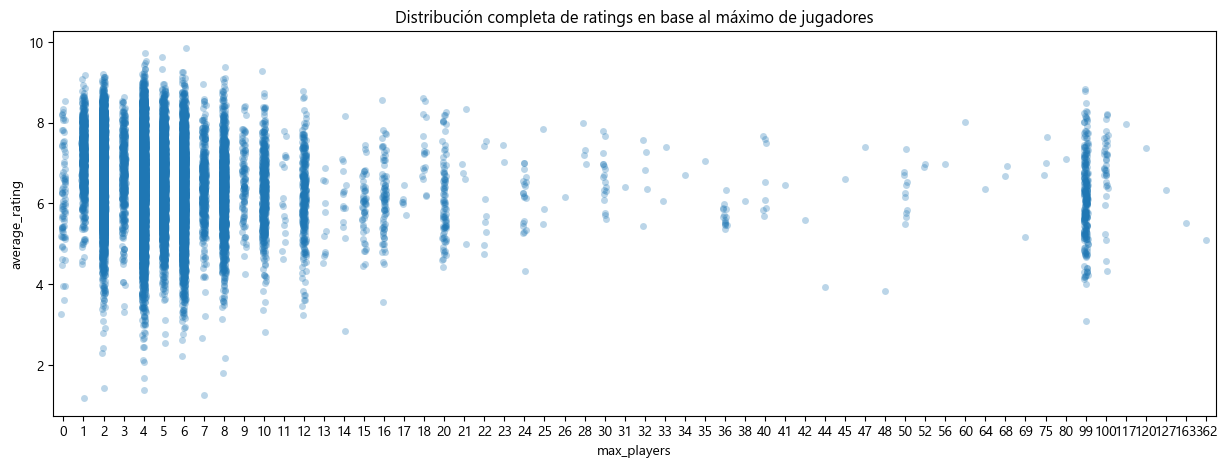

In [36]:
plt.figure(figsize=(15,5))

sns.stripplot(
    data=games_df,
    x="max_players",
    y="average_rating",
    jitter=True,
    alpha=0.3
)

plt.title("Distribución completa de ratings en base al máximo de jugadores")
plt.show()

# Incremento de interés en juegos

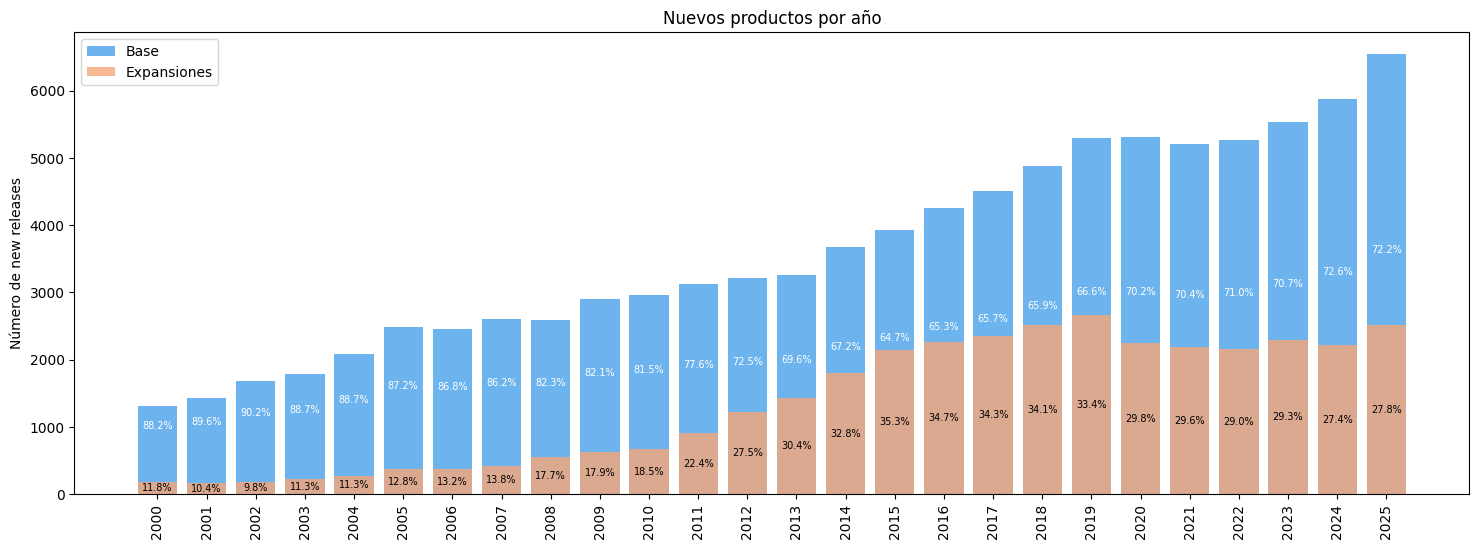

In [ ]:
base = bgg_total[bgg_total["type"] == "boardgame"]
exp = bgg_total[bgg_total["type"] == "boardgameexpansion"]

base_year = base["release_year"].value_counts().sort_index()
exp_year = exp["release_year"].value_counts().sort_index()

years = sorted(set(base_year.index).union(set(exp_year.index)))

base_vals = np.array([base_year.get(y, 0) for y in years])
exp_vals = np.array([exp_year.get(y, 0) for y in years])

total = base_vals + exp_vals

x = np.arange(len(years))

fig, ax = plt.subplots(figsize=(18,6))

# barras superpuestas
ax.bar(x, base_vals, color="#48a1ea", alpha=0.8, label="Base")
ax.bar(x, exp_vals, color="#F8A679E3", alpha=0.8, label="Expansiones")

offset = max(total) * 0.040
for i in range(len(years)):
    if total[i] > 0:
        ax.text(x[i], base_vals[i]/2 + offset,
                f"{base_vals[i]/total[i]*100:.1f}%",
                ha="center", va="center", fontsize=7, color="white")

        ax.text(x[i], exp_vals[i]/2,
                f"{exp_vals[i]/total[i]*100:.1f}%",
                ha="center", va="center", fontsize=7, color="black")

ax.set_xticks(x)
ax.set_xticklabels(years, rotation=90)

ax.set_ylabel("Número de new releases")
ax.set_title("Nuevos productos por año")
ax.legend()

## Vamos a analizar las dificultades y la popularidad, pero haciendo grupos según escala de dificultad

In [168]:
games_df["weight_bin"] = pd.cut(
    games_df["weight"],
    bins=[0, 1.5, 2.5, 5],
    labels=["Muy Fácil", "Asequible", "Complicado"]
)

grouped = games_df.groupby("weight_bin")["popularidad_total"].mean()

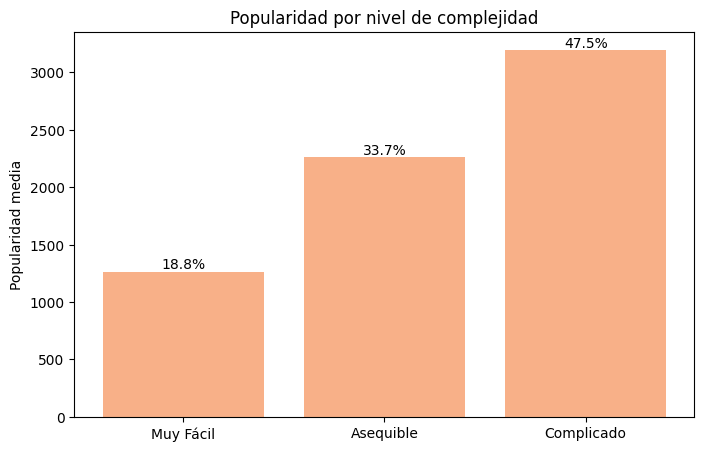

In [169]:
grouped = games_df.groupby("weight_bin")["popularidad_total"].mean()
percentages = grouped / grouped.sum() * 100

plt.figure(figsize=(8,5))

bars = plt.bar(
    grouped.index,
    grouped.values,
    color="#F8A679E3"
)

plt.ylabel("Popularidad media")
plt.title("Popularidad por nivel de complejidad")

for bar, pct in zip(bars, percentages):
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

## Vamos a aplicarlo a los df de los top 100 mejor valorados y más populares

In [97]:
top100_rating = games_df.head(100)
top100_pop = games_df.sort_values(by="popularidad_total", ascending=False).head(100)

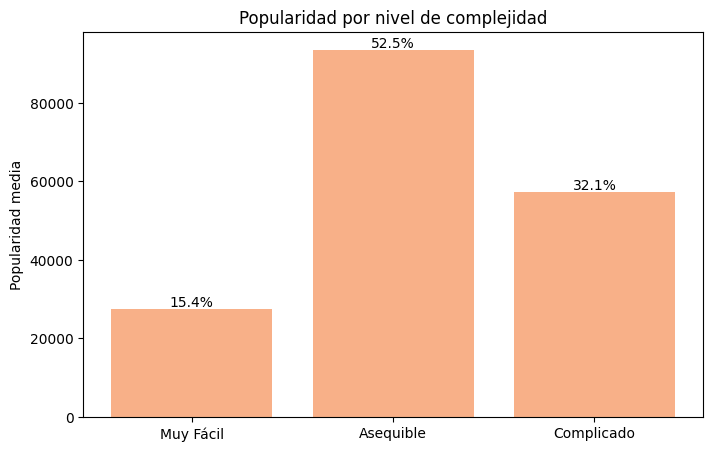

In [170]:
top100_rating["weight_bin"] = pd.cut(
    top100_rating["weight"],
    bins=[0, 1.5, 2.5, 5],
    labels=["Muy Fácil", "Asequible", "Complicado"]
)

grouped = top100_rating.groupby("weight_bin")["popularidad_total"].mean()

percentages = grouped / grouped.sum() * 100

plt.figure(figsize=(8,5))

bars = plt.bar(
    grouped.index,
    grouped.values,
    color="#F8A679E3"
)

plt.ylabel("Popularidad media")
plt.title("Popularidad por nivel de complejidad")

for bar, pct in zip(bars, percentages):
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

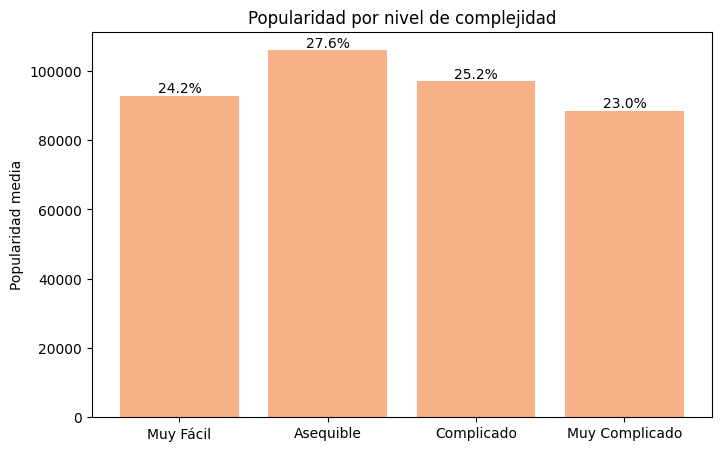

In [173]:
top100_pop["weight_bin"] = pd.cut(
    top100_pop["weight"],
    bins=[0, 1.5, 2.5, 3.5, 5],
    labels=["Muy Fácil", "Asequible", "Complicado", "Muy Complicado"]
)

grouped = top100_pop.groupby("weight_bin")["popularidad_total"].mean()

percentages = grouped / grouped.sum() * 100

plt.figure(figsize=(8,5))

bars = plt.bar(
    grouped.index,
    grouped.values,
    color="#F8A679E3"
)

plt.ylabel("Popularidad media")
plt.title("Popularidad por nivel de complejidad")

for bar, pct in zip(bars, percentages):
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

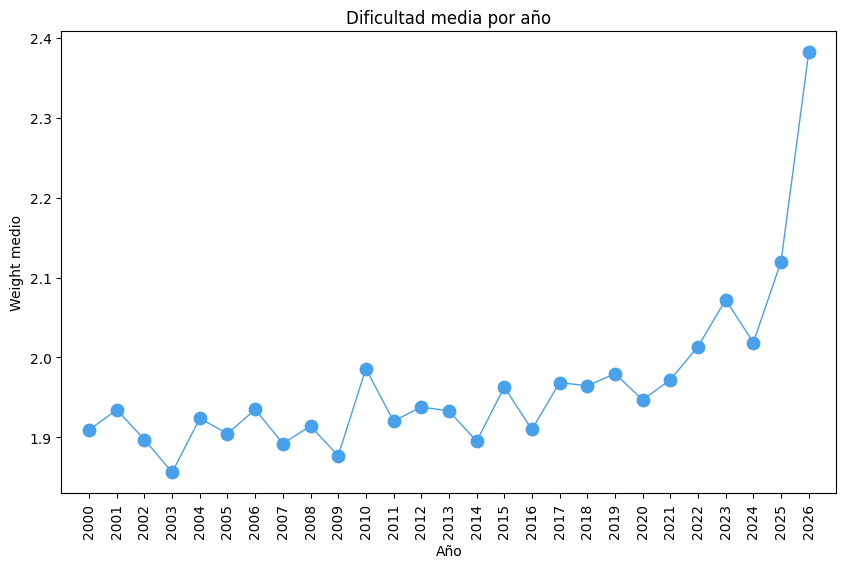

In [166]:
df_2000s = games_df.groupby("release_year", as_index=False)["weight"].mean()
df_2000s = df_2000s[
    (df_2000s["release_year"] > 1999) &
    (df_2000s["release_year"] < 2027)]

plt.figure(figsize=(10,6))

# puntos
plt.scatter(
    df_2000s["release_year"],
    df_2000s["weight"],
    color="#48a1ea",
    s=80
)

# línea que une los puntos
plt.plot(
    df_2000s["release_year"],
    df_2000s["weight"],
    color="#48a1ea",
    linewidth=1
)

plt.xlabel("Año")
plt.ylabel("Weight medio")
plt.title("Dificultad media por año")
plt.xticks(df_2000s["release_year"], rotation=90)
# límite superior del eje X
plt.xlim(1999, 2027)

plt.show()

## Opciones de visualización de frecuencias

In [194]:
import ast
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

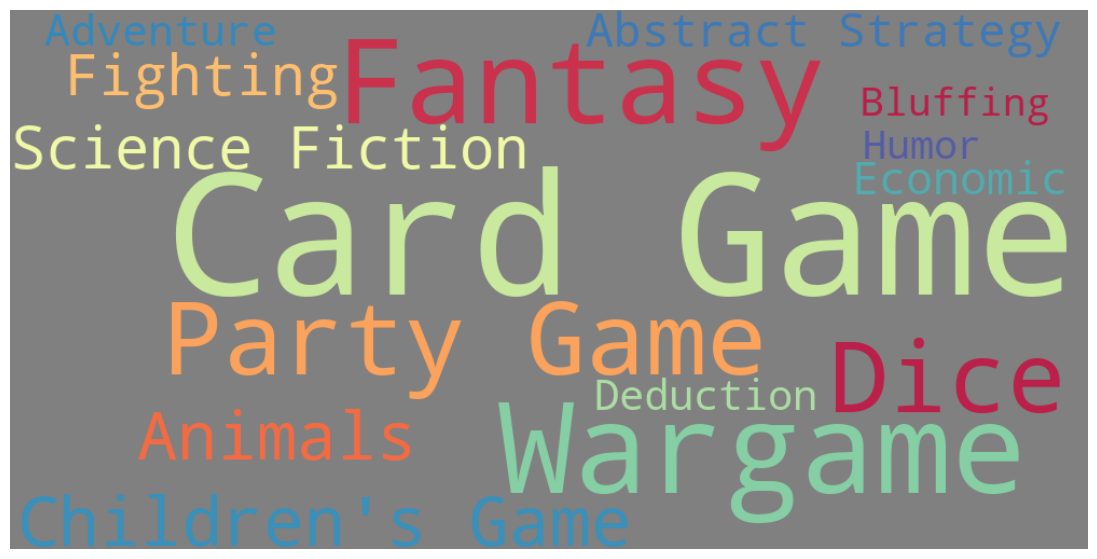

In [215]:
all_categories = []

for cats in games_df["categories"].dropna():

    all_categories.extend(cats)

category_counts = Counter(all_categories)

top20 = dict(category_counts.most_common(15))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="grey",
    colormap="Spectral"
).generate_from_frequencies(top20)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")


(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

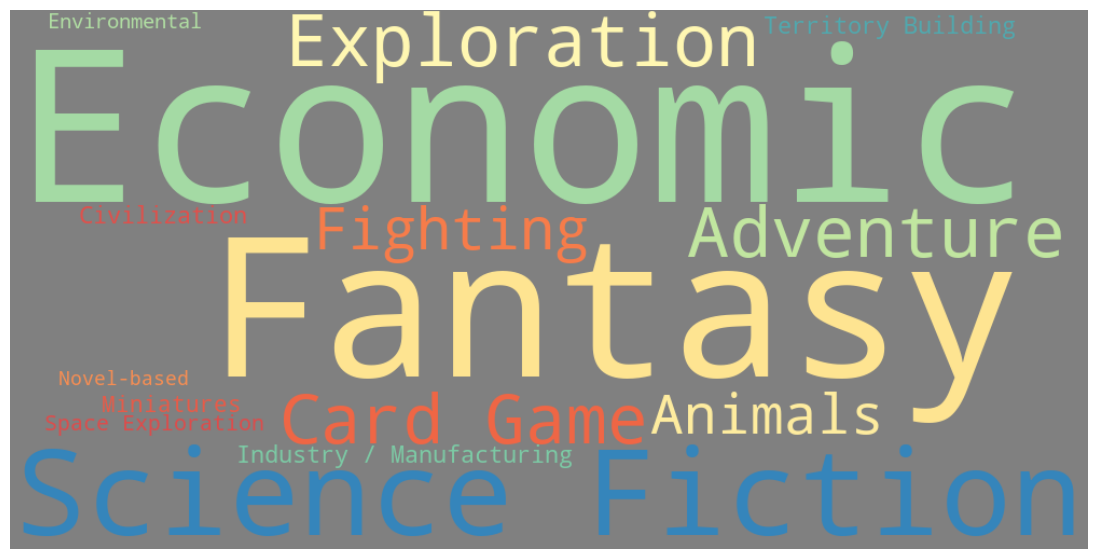

In [217]:
all_categories = []

for cats in top100_rating["categories"].dropna():

    all_categories.extend(cats)

category_counts = Counter(all_categories)

top20 = dict(category_counts.most_common(15))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="grey",
    colormap="Spectral"
).generate_from_frequencies(top20)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

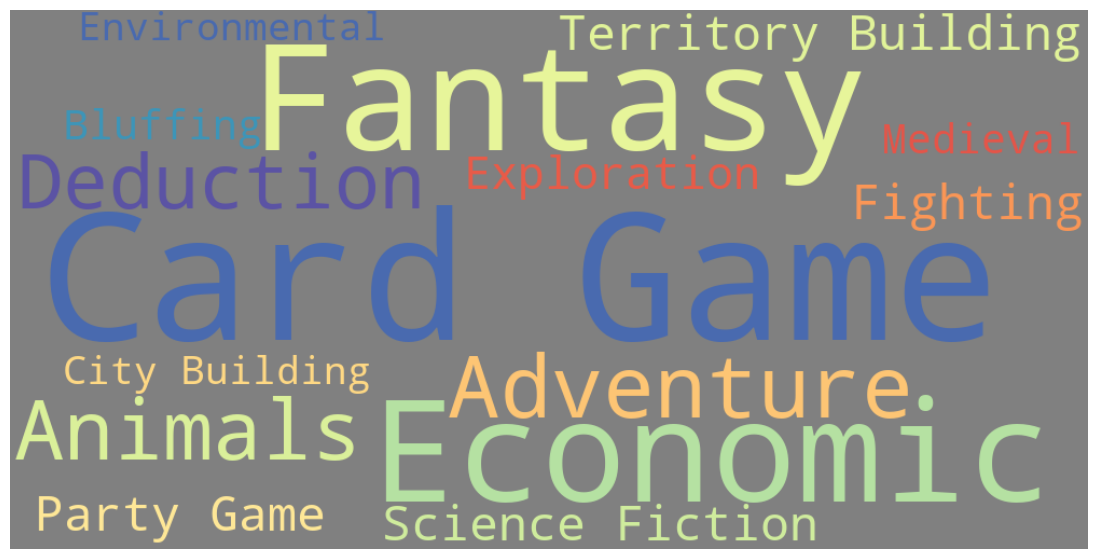

In [218]:
all_categories = []

for cats in top100_pop["categories"].dropna():

    all_categories.extend(cats)

category_counts = Counter(all_categories)

top20 = dict(category_counts.most_common(15))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="grey",
    colormap="Spectral"
).generate_from_frequencies(top20)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

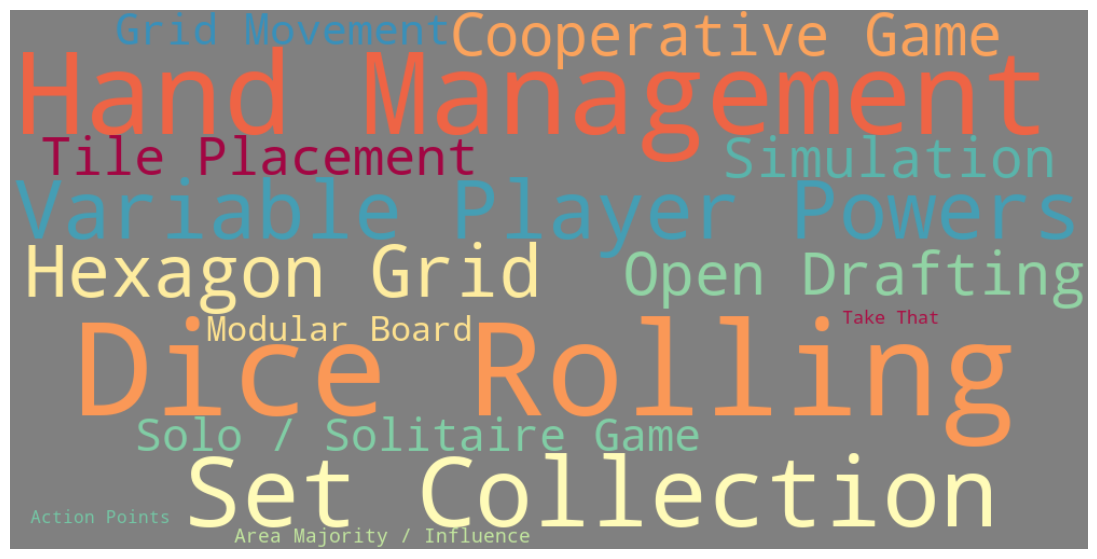

In [220]:
all_categories = []

for cats in games_df["mechanisms"].dropna():

    all_categories.extend(cats)

category_counts = Counter(all_categories)

top20 = dict(category_counts.most_common(15))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="grey",
    colormap="Spectral"
).generate_from_frequencies(top20)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

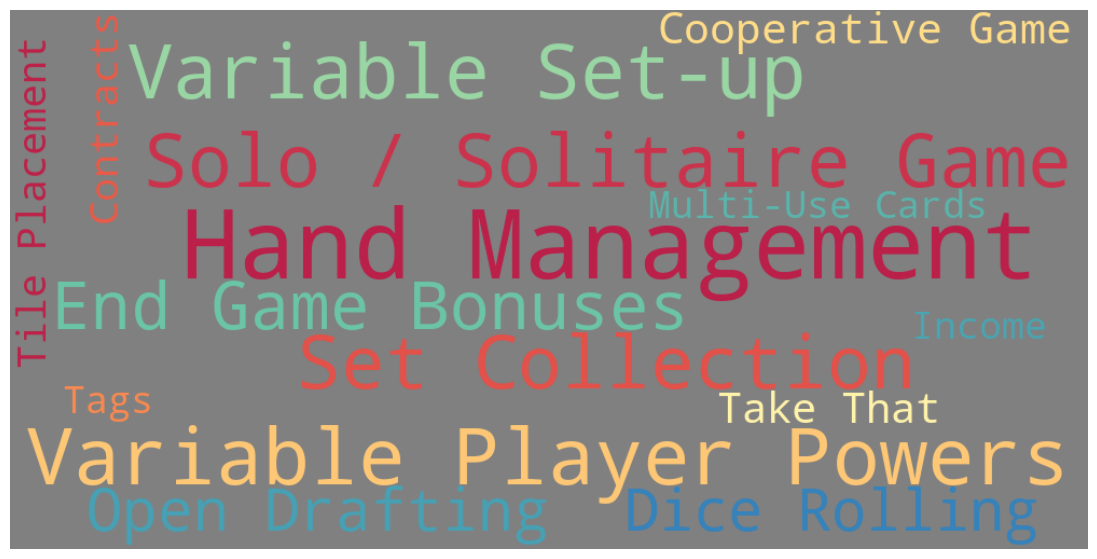

In [221]:
all_categories = []

for cats in top100_pop["mechanisms"].dropna():

    all_categories.extend(cats)

category_counts = Counter(all_categories)

top20 = dict(category_counts.most_common(15))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="grey",
    colormap="Spectral"
).generate_from_frequencies(top20)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

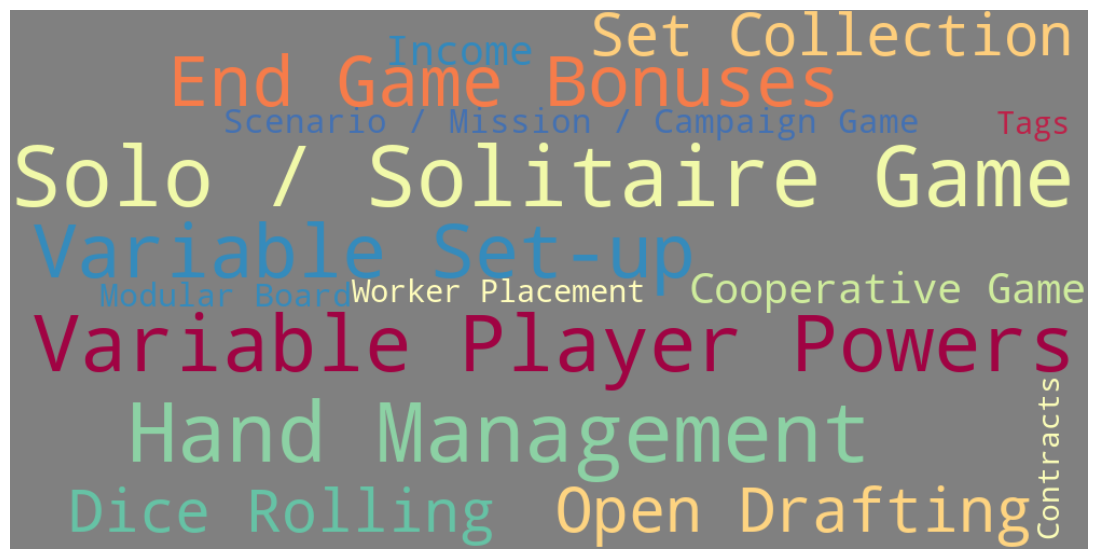

In [222]:
all_categories = []

for cats in top100_rating["mechanisms"].dropna():

    all_categories.extend(cats)

category_counts = Counter(all_categories)

top20 = dict(category_counts.most_common(15))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="grey",
    colormap="Spectral"
).generate_from_frequencies(top20)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

## Opciones de visualización: Violin plot y Strip plot

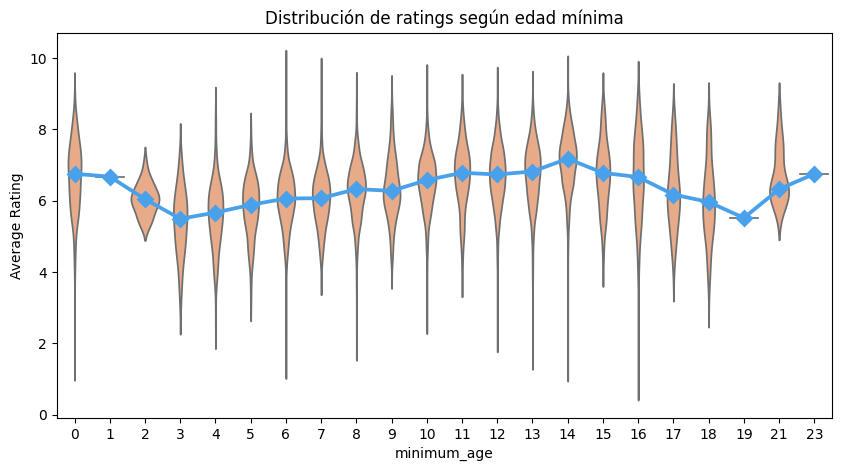

In [236]:
plt.figure(figsize=(10,5))

# violines
sns.violinplot(
    data=games_df,
    x="minimum_age",
    y="average_rating",
    color="#F8A679",
    inner=None
)

# línea de medianas
sns.pointplot(
    data=games_df,
    x="minimum_age",
    y="average_rating",
    estimator="median",
    errorbar=None,
    color="#48a1ea",
    markers="D",
    linestyles="-"
)

plt.title("Distribución de ratings según edad mínima")
plt.ylabel("Average Rating")

plt.show()

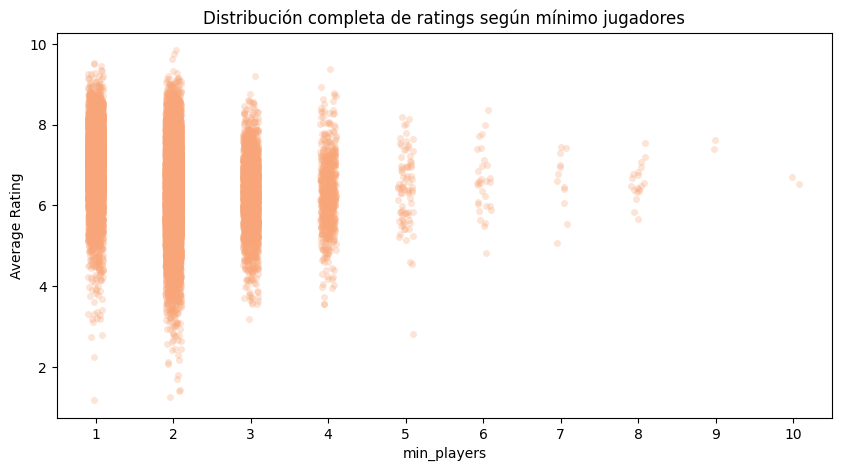

In [238]:
plt.figure(figsize=(10,5))

sns.stripplot(
    data=games_df,
    x="min_players",
    y="average_rating",
    jitter=True,
    alpha=0.3,
    color="#F8A679E3"
)

plt.title("Distribución completa de ratings según mínimo jugadores")
plt.ylabel("Average Rating")

plt.show()

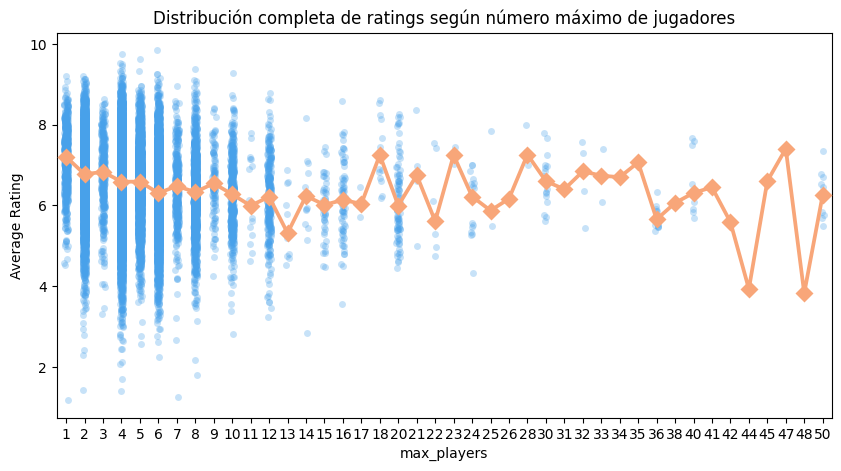

In [252]:
filtered = games_df[(games_df["max_players"] <= 51) & (games_df["max_players"] > 0)]

plt.figure(figsize=(10,5))

sns.stripplot(
    data=filtered,
    x="max_players",
    y="average_rating",
    jitter=True,
    alpha=0.3,
    color="#48a1ea",
    zorder=1
)

sns.pointplot(
    data=filtered,
    x="max_players",
    y="average_rating",
    estimator="median",
    errorbar=None,
    color="#F8A679" ,
    markers="D",
    linestyles="-",
    zorder=10
)

plt.title("Distribución completa de ratings según número máximo de jugadores")
plt.ylabel("Average Rating")

plt.show()

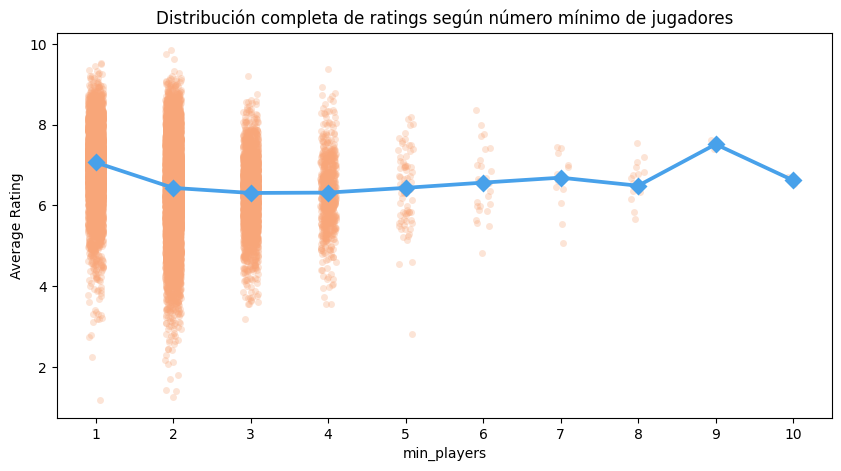

In [253]:
filtered = games_df[(games_df["min_players"] <= 51) & (games_df["min_players"] > 0)]

plt.figure(figsize=(10,5))

sns.stripplot(
    data=filtered,
    x="min_players",
    y="average_rating",
    jitter=True,
    alpha=0.3,
    color="#F8A679",
    zorder=1
)

sns.pointplot(
    data=filtered,
    x="min_players",
    y="average_rating",
    estimator="median",
    errorbar=None,
    color="#48a1ea",
    markers="D",
    linestyles="-",
    zorder=10
)

plt.title("Distribución completa de ratings según número mínimo de jugadores")
plt.ylabel("Average Rating")

plt.show()